In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 14})

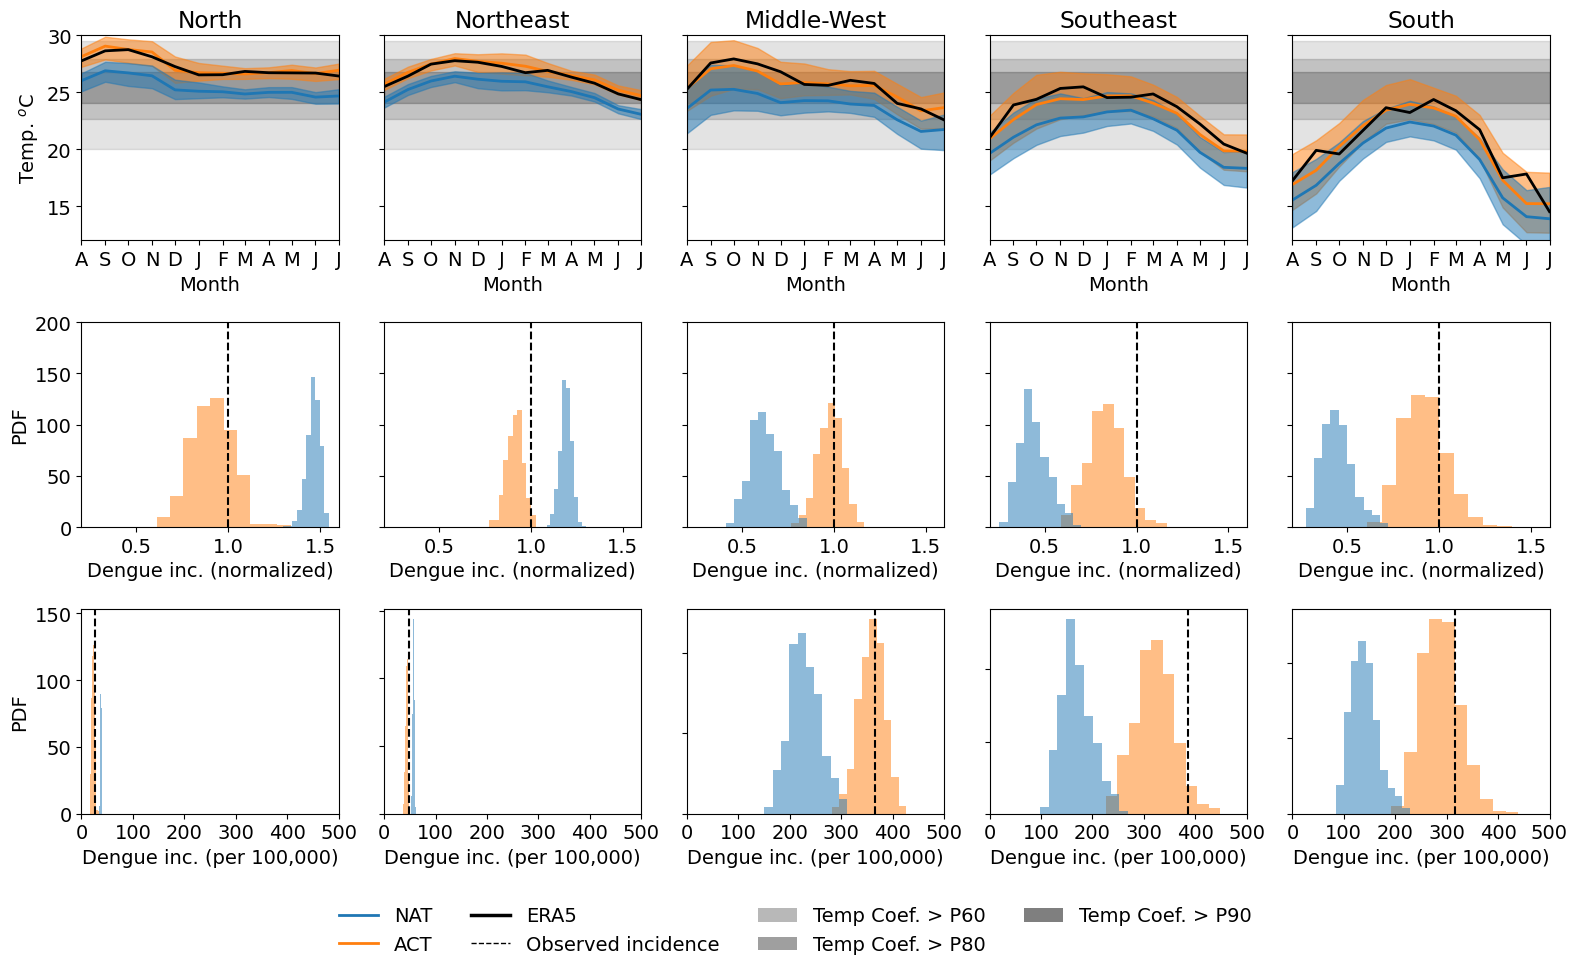

In [ ]:
fig, axarr = plt.subplots(3, 5, figsize=(16, 9))
plt.subplots_adjust(wspace=0.2)

# Temperature plots
ext = pd.read_csv('data/ext_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)
nat = pd.read_csv('data/nat_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)

obs = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
obs = obs.groupby(['region', 'date_first_symptoms']).mean(numeric_only=True).reset_index()

ext['time'] = ext['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))
nat['time'] = nat['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))

regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']

for i, region in enumerate(regions):
    ext_subset = ext[ext['region'] == region]
    nat_subset = nat[nat['region'] == region]

    ext_quantiles = ext_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()
    nat_quantiles = nat_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()

    ax = axarr[0, i]

    spans = [
        [0.6, 20, 29.5, '#737373'],
        [0.8, 22.7, 27.9, '#404040'],
        [0.9, 24.1, 26.8, '#000000']
    ]

    for span in spans:
        ax.axhspan(span[1], span[2], color=span[3], alpha=0.2)

    ax.fill_between(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'],
        ext_quantiles[ext_quantiles['level_1'] == 0.025]['tas'],
        ext_quantiles[ext_quantiles['level_1'] == 0.975]['tas'],
        color='C1', alpha=0.5
    )
    ax.plot(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'], 
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['tas'],
        color='C1', lw=2
    )

    ax.fill_between(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'],
        nat_quantiles[nat_quantiles['level_1'] == 0.025]['tas'],
        nat_quantiles[nat_quantiles['level_1'] == 0.975]['tas'],
        color='C0', alpha=0.5
    )
    ax.plot(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'], 
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['tas'],
        color='C0', lw=2
    )

    ax.plot(
        obs[obs['region'] == region]['date_first_symptoms'],
        obs[obs['region'] == region]['mean_2m_air_temp_degree1'],
        color='k', lw=2
    )

    ax.set_xlim(pd.to_datetime('2023-08-01'), pd.to_datetime('2024-07-31'))
    ax.set_xticks(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='4MS')
    )
    ax.set_xticklabels(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='4MS').strftime('%m/%y')
    )

    ax.set_title(region)
    ax.set_xlim(pd.to_datetime('2023-08-01'), pd.to_datetime('2024-07-01'))
    ax.set_xticks(pd.date_range('2023-08-01', '2024-07-31', freq='MS'))
    ax.set_xticklabels(list('ASONDJFMAMJJ'))
    ax.set_xlabel('Month')
    ax.set_ylim([12, 30])

# Add dengue incidence plots
ext = pd.read_csv('data/all_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
nat = pd.read_csv('data/nat_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
act = pd.read_csv('data/dengue_regional_aggregation.csv', parse_dates=['date_first_symptoms'])

ext = ext[ext['region'].isin(regions)]
nat = nat[nat['region'].isin(regions)]
act = act[act['region'].isin(regions) & (act['date_first_symptoms'] >= '2023-08-01') & (act['date_first_symptoms'] <= '2024-07-01')]

ext['predicted_incidence'] = ext['predicted_incidence'] * ext['total_population'] / 1e5
nat['predicted_incidence'] = nat['predicted_incidence'] * nat['total_population'] / 1e5
act['actual_incidence'] = act['actual_regional_incidence'] * act['total_population'] / 1e5

ext = ext.groupby(['region', 'file_number']).agg({'predicted_incidence': 'sum', 'total_population': 'sum'}).reset_index()
nat = nat.groupby(['region', 'file_number']).agg({'predicted_incidence': 'sum', 'total_population': 'sum'}).reset_index()
act = act.groupby(['region']).agg({'total_population': 'sum', 'actual_incidence': 'sum'}).reset_index()

ext['predicted_incidence'] = 1e5 * ext['predicted_incidence'] / ext['total_population']
nat['predicted_incidence'] = 1e5 * nat['predicted_incidence'] / nat['total_population']
act['actual_incidence'] = 1e5 * act['actual_incidence'] / act['total_population']

for ax, region in zip(axarr[1], regions):    
    act_region = act[act['region'] == region]['actual_incidence'].values[0]
    
    ax.hist(ext[ext['region'] == region]['predicted_incidence'] / act_region, color='C1', alpha=0.5)
    ax.hist(nat[nat['region'] == region]['predicted_incidence'] / act_region, color='C0', alpha=0.5)

    ax.axvline(1, color='k', ls='--')
    ax.set_xlabel('Dengue inc. (normalized)')
    ax.set_ylim([0, 200])
    ax.set_xlim([0.2, 1.6])

for ax, region in zip(axarr[2], regions):    
    act_region = act[act['region'] == region]['actual_incidence'].values[0]
    
    ax.hist(ext[ext['region'] == region]['predicted_incidence'], color='C1', alpha=0.5)
    ax.hist(nat[nat['region'] == region]['predicted_incidence'], color='C0', alpha=0.5)

    ax.axvline(act_region, color='k', ls='--')
    ax.set_xlabel('Dengue inc. (per 100,000)')
    ax.set_xlim([0, 500])
    ax.set_xticks([0, 100, 200, 300, 400, 500])

axarr[0, 0].set_ylabel(r'Temp. $^o$C')
axarr[1, 0].set_ylabel('PDF')
axarr[2, 0].set_ylabel('PDF')

for i in range(1,5):
    axarr[0, i].set_yticklabels([])
    axarr[1, i].set_yticklabels([])
    axarr[2, i].set_yticklabels([])

legend_elements = []

legend_elements.append(Line2D([0], [0], color='C0', lw=2, label='NAT'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2, label='ACT'))
legend_elements.append(Line2D([0], [0], color='k', lw=2.5, label='ERA5'))
legend_elements.append(Line2D([0], [0], color='k', ls='--', lw=1, label='Observed incidence'))
legend_elements.append(Patch(facecolor='#737373', alpha=0.5, label='Temp Coef. > P60'))
legend_elements.append(Patch(facecolor='#404040', alpha=0.5, label='Temp Coef. > P80'))
legend_elements.append(Patch(facecolor='#000000', alpha=0.5, label='Temp Coef. > P90'))

# Place legend on the figure level or first axis
fig.legend(handles=legend_elements, frameon=False, ncol=4, bbox_to_anchor=(0.8, -0.001))

plt.tight_layout()